In [1]:
import onnxruntime as ort
import numpy as np
import matplotlib.pyplot as plt
import cv2

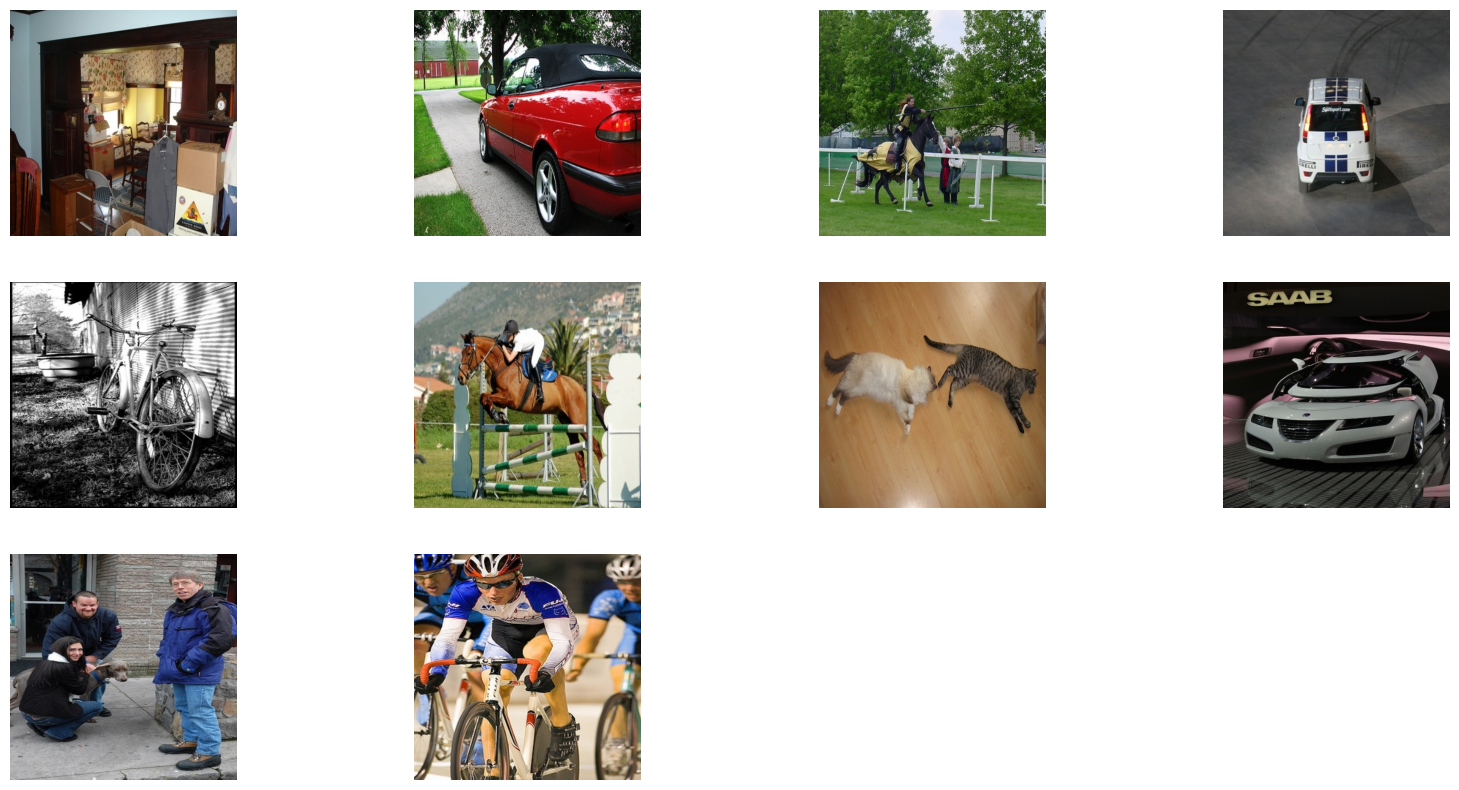

In [2]:
# Load the Images
IMAGE_FOLDER = 'images/'

# # Files are 1.jpg to 10.jpg
images = [cv2.imread(IMAGE_FOLDER + str(i) + '.jpg') for i in range(1, 11)]
images = [cv2.cvtColor(img, cv2.COLOR_BGR2RGB) for img in images]

# Plot the images
plt.figure(figsize=(20, 10))
for i in range(10):
    plt.subplot(3, 4, i+1)
    plt.imshow(images[i])
    plt.axis('off')
plt.show()


In [3]:
# Preprocess the images

def preprocess_image(image):
    # convert to numpy array
    image = np.array(image)
    image = image.astype(np.float32)

    # resize the image
    image = image.transpose(2, 0, 1)

    # normalize the image
    image = np.expand_dims(image, axis=0)

    # print("Image shape:", image.shape) # (1, 3, 416, 416)

    return image


# Preprocess all the images
images_np = [preprocess_image(image) for image in images]

In [4]:
# Load the model
# model_path = 'yolo.onnx' # tiny-yolov2
model_path = 'tinyyolov2.onnx' # tiny-yolov2-8

# Create a onnxruntime session
so = ort.SessionOptions()
so.log_severity_level = 3
session = ort.InferenceSession(model_path, so)

# Get the Model Information
input_name = session.get_inputs()[0].name
output_name = session.get_outputs()[0].name

def run_model(image):
    # Run the model
    output = session.run([output_name], {input_name: image})
    output = np.squeeze(output)
    return output

outputs = np.array([run_model(image) for image in images_np])

print("Input Shape: ", images_np[0].shape) # (1, 3, 416, 416)
print("Output Shape: ", outputs[0].shape) # (125, 13, 13)

Input Shape:  (1, 3, 416, 416)
Output Shape:  (125, 13, 13)


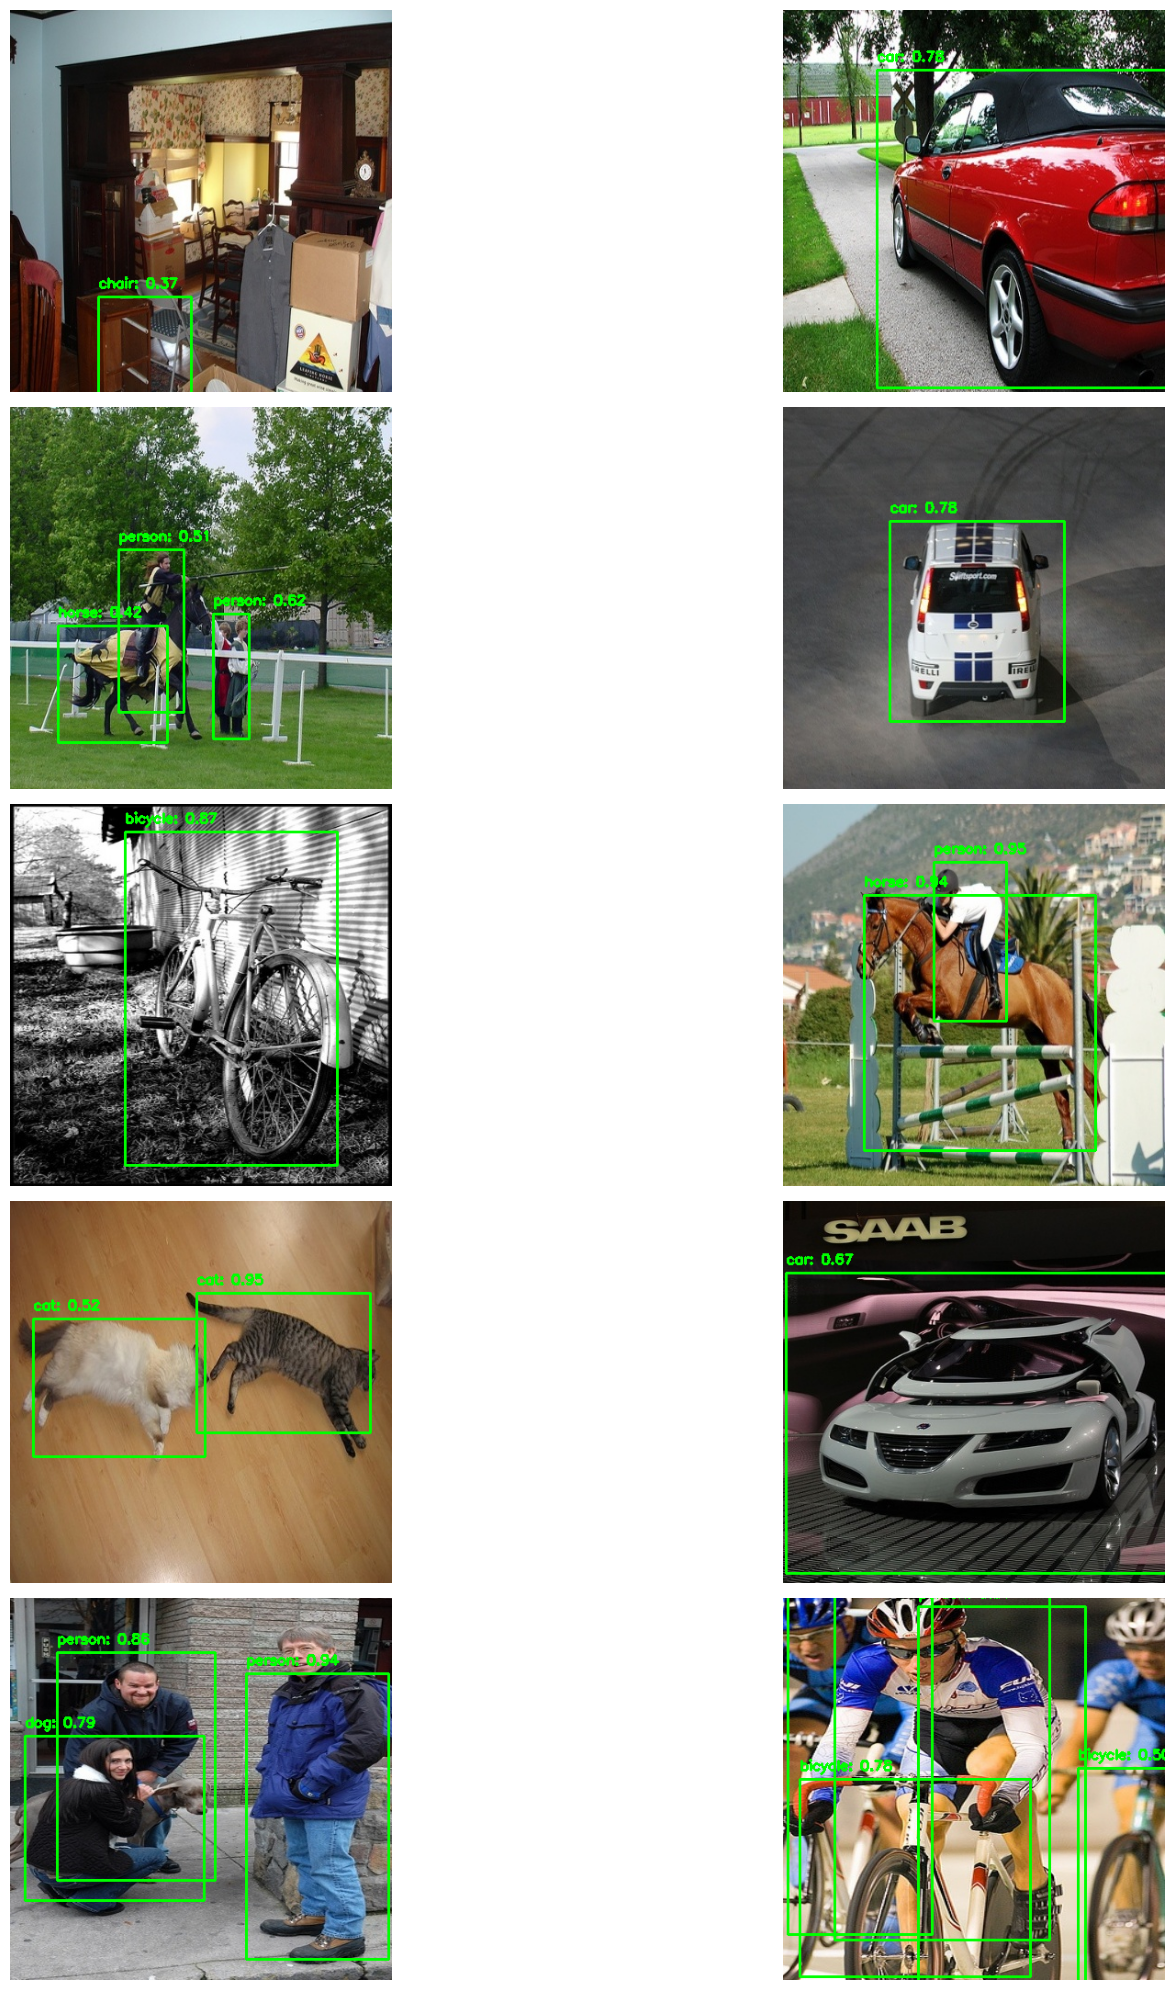

In [6]:
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def softmax(x):
    e_x = np.exp(x - np.max(x))
    return e_x / e_x.sum(axis=0)

num_classes = 20
grid_size = 13
score_threshold = 0.3
iou_threshold = 0.4

classes = ['aeroplane', 'bicycle', 'bird', 'boat', 'bottle', 'bus', 'car', 'cat', 'chair', 'cow',
              'diningtable', 'dog', 'horse', 'motorbike', 'person', 'pottedplant', 'sheep', 'sofa', 'train', 'tvmonitor']

# anchors = [0.57273, 0.677385, 1.87446, 2.06253, 3.33843, 5.47434, 7.88282, 3.52778, 9.77052, 9.16828] # tiny-yolov2
anchors = [1.08, 1.19, 3.42, 4.41, 6.63, 11.38, 9.42, 5.11, 16.62, 10.52] # tiny-yolov2-8

def decodeOutput(output, image, with_nms=True):
    predictions = []

    for cy in range(grid_size):
        for cx in range(grid_size):
            for b in range(5):
                channel = b * (num_classes + 5)
                tx = output[channel][cy][cx]
                ty = output[channel + 1][cy][cx]
                tw = output[channel + 2][cy][cx]
                th = output[channel + 3][cy][cx]
                tc = output[channel + 4][cy][cx]
                class_preds = output[channel + 5:channel + 5 + num_classes, cy, cx]
                
                x = (float(cx) + sigmoid(tx)) * 32.0
                y = (float(cy) + sigmoid(ty)) * 32.0

                w = np.exp(tw) * 32.0 * anchors[2*b]
                h = np.exp(th) * 32.0 * anchors[2*b + 1]

                confidence = sigmoid(tc)

                class_preds = softmax(class_preds)
                best_class = np.argmax(class_preds)
                best_class_score = class_preds[best_class]
                best_class_name = classes[best_class]
                
                left = int(x - w / 2.0)
                right = int(x + w / 2.0)
                top = int(y - h / 2.0)
                bottom = int(y + h / 2.0)

                final_confidence = confidence * best_class_score

                if final_confidence > score_threshold:
                    predictions.append([[left, top, right, bottom], final_confidence, best_class_name, best_class_score, confidence])

    if with_nms and predictions:
        boxes = [pred[0] for pred in predictions]
        scores = [pred[1] for pred in predictions]

        indices = cv2.dnn.NMSBoxes(boxes, scores, score_threshold, iou_threshold)

        nms_predictions = [predictions[i] for i in indices.flatten()]
        predictions = nms_predictions

    return predictions

def drawBoundingBoxes(image, predictions):
    for pred in predictions:
        left, top, right, bottom = pred[0]
        final_confidence = pred[1]
        best_class_name = pred[2]
        cv2.rectangle(image, (left, top), (right, bottom), (0, 255, 0), 2)
        label = f"{best_class_name}: {final_confidence:.2f}"
        cv2.putText(image, label, (left, top - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 2)
    return image

def decodeAndDraw(image, output):
    decodedOutput = decodeOutput(output, image, with_nms=True)
    image_with_boxes = drawBoundingBoxes(image, decodedOutput)
    return image_with_boxes

images_with_boxes = [decodeAndDraw(images[i].copy(), outputs[i]) for i in range(10)]

# Plot the images
plt.figure(figsize=(20, 20))
for i in range(10):
    plt.subplot(5, 2, i+1)
    plt.imshow(images_with_boxes[i])
    plt.axis('off')
plt.tight_layout()
plt.show()

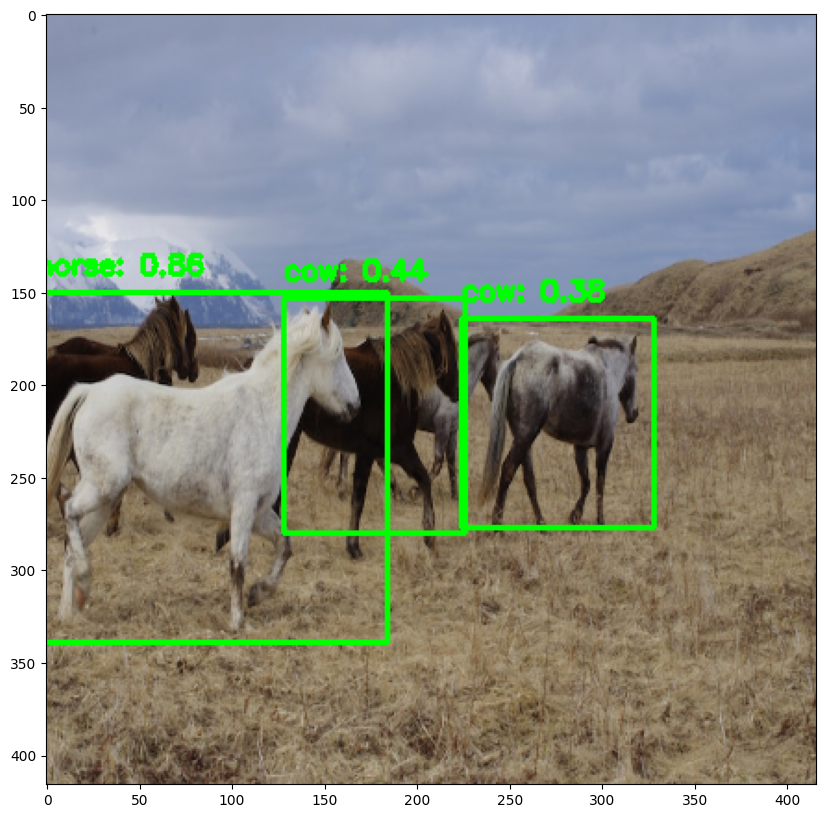

In [7]:
image = cv2.imread('horses.jpg')
image = cv2.resize(image, (416, 416))
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

image_np = preprocess_image(image)
output = run_model(image_np)
decoded_output = decodeOutput(output, image, with_nms=True)
image_with_boxes = drawBoundingBoxes(image.copy(), decoded_output)

plt.figure(figsize=(10, 10))
plt.imshow(image_with_boxes)

In [8]:
camera_run = False

if camera_run:
    print("Starting camera...")
    cap = cv2.VideoCapture(0)
    
    while True:
        ret, frame = cap.read()
        if not ret:
            break

        frame = cv2.resize(frame, (416, 416))

        frame_np = preprocess_image(frame)
        output = run_model(frame_np)
        decoded_output = decodeOutput(output, frame, with_nms=True)
        frame_with_boxes = drawBoundingBoxes(frame.copy(), decoded_output)

        cv2.imshow('frame', frame_with_boxes)
        if cv2.waitKey(1) & 0xFF == ord('q'):
            print("Stopping camera...")
            break

    cap.release()
    cv2.destroyAllWindows()

print("Done")

Done
